# Imports

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
import warnings
warnings.simplefilter(action='ignore')
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import shapiro, f_oneway, kruskal
import scikit_posthocs as sp
from collections import Counter
from sklearn.manifold import TSNE
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import os
import together
together.api_key = os.environ.get("TOGETHER_API_KEY")
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pingouin as pg
import inflect
from scipy.stats import spearmanr
from PIL import Image

rcParams["text.usetex"] = True
rcParams["font.family"] = "sans-serif"
rcParams["grid.linestyle"] = ":"
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"
rcParams["legend.fontsize"] = 13
rcParams["axes.labelsize"] = 18
rcParams["axes.titlesize"] = 20
rcParams["xtick.labelsize"] = 15
rcParams["ytick.labelsize"] = 15

# Functions

In [2]:
def determine_subgroup(row):
    if row["creator"] == "children":
        if row["age"] in [4, 5, 6]:
            return "pre-schematic"
        elif row["age"] in [7, 8, 9]:
            return "schematic"
    elif row["creator"] == "adults":
        return "adults"
    elif row["creator"] == "AI_prompt1":
        return "prompt1"
    elif row["creator"] == "AI_prompt2":
        return "prompt2"
    elif row["creator"] == "AI_prompt3":
        return "prompt3"
    return None

def significance_test(groups):
    if all(shapiro(group)[1] > 0.05 for group in groups):
        print("\nPerforming One-Way ANOVA:")
        stat, p = f_oneway(groups[0], groups[1], groups[2])
    else:  # If normality is violated
        print("\nPerforming Kruskal-Wallis Test:")
        stat, p = kruskal(groups[0], groups[1], groups[2])
    
    print("Test Statistic:", stat)
    print("p-value:", p)
    if p < 0.05:
        print("The groups are significantly different:")
    else:
        print("No significant difference between the groups:")
    
    dunn = sp.posthoc_dunn(groups, p_adjust='bonferroni')
    print(dunn)

def remove_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

def var_to_title(text):
    return " ".join(word.capitalize() for word in text.replace("_", " ").split())

def boxplot(values, measure, move, title=None):
    fig, ax = plt.subplots(figsize=(4, 3))
    bp = ax.boxplot(values, positions=positions, patch_artist=True, widths = 0.3, showfliers=False)
    for box, color in zip(bp['boxes'], colors):
        box.set(facecolor=color)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_xticks(positions)
    ax.set_xticklabels([f' ' for i in range(6)])
    ax.text((positions[0] + positions[1]) / 2, min(min(d) for d in values) - move, "Children", 
            ha='center', va='top', fontsize=18, fontweight='bold', color='black')

    ax.text(positions[2], min(min(d) for d in values) - move, "Adults", 
            ha='center', va='top', fontsize=18, fontweight='bold', color='black')

    ax.text(positions[4], min(min(d) for d in values) - move, "AI", 
            ha='center', va='top', fontsize=18, fontweight='bold', color='black')
    x_min = positions[0] - 0.3
    x_max = positions[-1] + 0.3
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Creator", labelpad=10, fontsize=20)
    if title is None:
        ax.set_ylabel(var_to_title(measure), labelpad=10, fontsize=20)
    else:
        ax.set_ylabel(title, labelpad=10, fontsize=20)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"../../figures/{measure}.png", bbox_inches='tight', dpi=1000)

def singularize_word(word):
    singular = p.singular_noun(word)
    return singular if singular else word

def get_spearman_corr(x, y):
    return spearmanr(x, y)

def calculate_icc(group1, group2):
    assert len(group1) == len(group2)
    icc = pd.DataFrame({
        'subject': range(len(group1)),
        'rater1': group1,
        'rater2': group2
    }).melt(id_vars=['subject'], var_name='rater', value_name='rating')
    icc_result = pg.intraclass_corr(data=icc, targets='subject', raters='rater', ratings='rating')
    return icc_result

# Load csvs

In [3]:
children_product = pd.read_csv("../../csvs/children_product.csv")
children_process = pd.read_csv("../../csvs/children_process.csv")
adults_product = pd.read_csv("../../csvs/adults_product.csv")
adults_process = pd.read_csv("../../csvs/adults_process.csv")
AI_product = pd.read_csv("../../csvs/AI_product.csv")
AI_process = pd.read_csv("../../csvs/AI_process.csv")

product = pd.concat([children_product, adults_product, AI_product], ignore_index=True)

# Add columns

In [4]:
product["gpt_hard_to_interpret"] = ((product["gpt_caption"] == "Hard to interpret") | (product["gpt_caption"].str.contains("abstract", case=False, na=False))).astype(int)
product["category_hard_to_interpret"] = (product["category1"].str.contains("abstract", case=False, na=False) | children_product["category1"].str.contains("blank", case=False, na=False) | children_product["category1"].str.contains("tracing", case=False, na=False)).astype(int)
product["creativity"] = product["creativity"].astype(float)
product.loc[product["creativity"] > 4, "creativity"] = 0
product["mean_creativity"] = (product["creativity"] + product["creativity2"]) / 2
product['mean_creativity'] = (product['mean_creativity'] - product['mean_creativity'].min()) / (product['mean_creativity'].max() - product['mean_creativity'].min())
product["mean_originality"] = (product["originality_audra"] + product["originality_ocs"]) / 2
product = product.rename(columns={"ink_fraction_inside_mask": "ink_fraction_inside_stimulus", "used_mask": "used_stimulus"})
product["subgroup"] = product.apply(determine_subgroup, axis=1)
product["creator"] = product["creator"].replace({"AI_prompt1": "AI", "AI_prompt2": "AI", "AI_prompt3": "AI"})
# product.to_csv("../../csvs/all_product.csv", index=False)

children_process["mean_flexibility"] = (children_process["flexibility_manual"] + children_process["flexibility_categories"]) / 2
adults_process["mean_flexibility"] = (adults_process["flexibility_manual"] + adults_process["flexibility_categories"]) / 2
AI_process["mean_flexibility"] = (AI_process["flexibility_manual"] + AI_process["flexibility_category"]) / 2
children_process["subgroup"] = children_process["age"].apply(lambda age: "pre-schematic" if age in [4, 5, 6] else "schematic")
adults_process["subgroup"] = "adults"
AI_process["subgroup"] = AI_process["image1"].str[14:20] + AI_process["image1"].str[21]

In [5]:
product.columns

Index(['pid', 'creator', 'age', 'stimuli', 'inverted', 'filename', 'filepath',
       'blip_caption', 'blip_caption_correct', 'gpt_caption',
       'gpt_caption_correct', 'gpt_caption_confidence', 'originality_audra',
       'originality_ocs', 'percentile_ocs', 'category1', 'category2',
       'category3', 'confidence', 'creativity', 'creativity2', 'used_stimulus',
       'line_thickness', 'ink_density', 'ink_fraction_inside_stimulus',
       'number_of_components', 'number_of_lines',
       'dist_from_base_caption_gtelarge', 'dist_from_base_caption_gte',
       'dist_from_base_caption_stella', 'dist_from_base_shape_dino',
       'dist_from_base_shape_clip', 'text_10NN_gtelarge', 'image_10NN_dino',
       'image_10NN_clip', 'inverse_category_frequency',
       'inverse_cluster_frequency_gtelarge', 'gpt_hard_to_interpret',
       'category_hard_to_interpret', 'mean_creativity', 'mean_originality',
       'subgroup'],
      dtype='object')

# Define variables

In [6]:
creators = ["children", "adults", "AI"]
subgroups = ["pre-schematic", "schematic", "adults", "prompt1", "prompt2", "prompt3"]
colors = ["aquamarine", "mediumaquamarine", "salmon", "xkcd:pale lavender", "xkcd:pastel purple", "mediumpurple"]
positions = [1, 1.3, 2, 2.7, 3, 3.3]

In [7]:
# - category and caption overlap
# - aesthetics entropy/symm measure
# - preprocessing problems
# - classifier
# - regression, table
# % TODO: Within human drawings, do objects/figures get higher ratings, and what about the children drawings that draw eyes on frech fries etc ie mix the two?

# Analysis

# Q1. How do Children, Adults, AI Drawings Differ?

## 1. Style

### Line Thickness

In [8]:
measure = "line_thickness"
values = [product[product["creator"] == x][measure] for x in creators]
significance_test(values)


Performing Kruskal-Wallis Test:
Test Statistic: 2.195370338808061
p-value: 0.33364251639066417
No significant difference between the groups:
          1         2         3
1  1.000000  0.522507  0.699137
2  0.522507  1.000000  1.000000
3  0.699137  1.000000  1.000000


### Ink Density


Performing Kruskal-Wallis Test:
Test Statistic: 19.16068603501744
p-value: 6.907325032796251e-05
The groups are significantly different:
              1             2             3             4             5  \
1  1.000000e+00  1.000000e+00  6.251563e-03  1.599296e-24  1.293463e-22   
2  1.000000e+00  1.000000e+00  1.361457e-03  1.090449e-19  4.503316e-18   
3  6.251563e-03  1.361457e-03  1.000000e+00  8.795014e-46  6.377714e-43   
4  1.599296e-24  1.090449e-19  8.795014e-46  1.000000e+00  1.000000e+00   
5  1.293463e-22  4.503316e-18  6.377714e-43  1.000000e+00  1.000000e+00   
6  1.984679e-14  3.435761e-11  2.569714e-30  3.945121e-01  9.795346e-01   

              6  
1  1.984679e-14  
2  3.435761e-11  
3  2.569714e-30  
4  3.945121e-01  
5  9.795346e-01  
6  1.000000e+00  


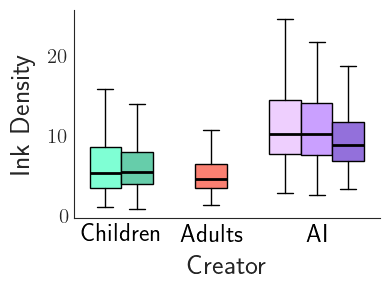

In [9]:
measure = "ink_density"
values = [product[product["subgroup"] == x][measure] for x in subgroups]
significance_test(values)
boxplot(values, measure, 2)

### Ink Fraction Inside Stimulus


Performing Kruskal-Wallis Test:
Test Statistic: 16.19820161680448
p-value: 0.00030381220067081437
The groups are significantly different:
          1             2             3             4             5  \
1  1.000000  2.477960e-03  8.829908e-01  4.999663e-06  6.634804e-05   
2  0.002478  1.000000e+00  2.126199e-01  5.869005e-15  2.885381e-13   
3  0.882991  2.126199e-01  1.000000e+00  1.295267e-11  6.581714e-10   
4  0.000005  5.869005e-15  1.295267e-11  1.000000e+00  1.000000e+00   
5  0.000066  2.885381e-13  6.581714e-10  1.000000e+00  1.000000e+00   
6  0.070401  3.203251e-08  4.626534e-05  6.309802e-01  1.000000e+00   

              6  
1  7.040121e-02  
2  3.203251e-08  
3  4.626534e-05  
4  6.309802e-01  
5  1.000000e+00  
6  1.000000e+00  


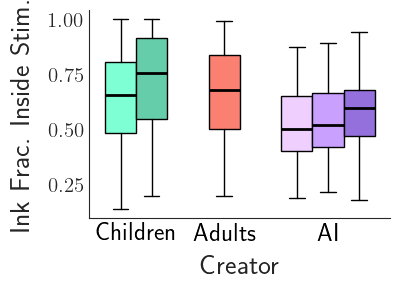

In [10]:
measure = "ink_fraction_inside_stimulus"
values = [product[product["subgroup"] == x][measure] for x in subgroups]
significance_test(values)
boxplot(values, measure, 0.07, "Ink Frac. Inside Stim.")

### Number of Components


Performing Kruskal-Wallis Test:
Test Statistic: 21.573231370591696
p-value: 2.0674372146143995e-05
The groups are significantly different:
              1             2             3             4             5  \
1  1.000000e+00  1.000000e+00  1.971337e-02  1.886738e-15  3.766757e-10   
2  1.000000e+00  1.000000e+00  3.047705e-04  9.525603e-18  2.616928e-12   
3  1.971337e-02  3.047705e-04  1.000000e+00  3.113701e-09  6.239547e-05   
4  1.886738e-15  9.525603e-18  3.113701e-09  1.000000e+00  1.000000e+00   
5  3.766757e-10  2.616928e-12  6.239547e-05  1.000000e+00  1.000000e+00   
6  1.042146e-15  5.219304e-18  1.882645e-09  1.000000e+00  1.000000e+00   

              6  
1  1.042146e-15  
2  5.219304e-18  
3  1.882645e-09  
4  1.000000e+00  
5  1.000000e+00  
6  1.000000e+00  


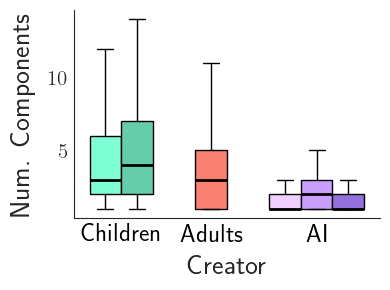

In [11]:
measure = "number_of_components"
values = [product[product["subgroup"] == x][measure] for x in subgroups]
significance_test(values)
boxplot(values, measure, 1.1, "Num. Components")

### Number of Lines


Performing Kruskal-Wallis Test:
Test Statistic: 2.8152129041220926
p-value: 0.24472835172114563
No significant difference between the groups:
              1             2             3             4             5  \
1  1.000000e+00  1.000000e+00  1.000000e+00  1.808663e-28  3.508194e-36   
2  1.000000e+00  1.000000e+00  1.000000e+00  8.122463e-32  1.742871e-39   
3  1.000000e+00  1.000000e+00  1.000000e+00  1.341003e-38  2.254247e-48   
4  1.808663e-28  8.122463e-32  1.341003e-38  1.000000e+00  1.000000e+00   
5  3.508194e-36  1.742871e-39  2.254247e-48  1.000000e+00  1.000000e+00   
6  1.725785e-14  1.382571e-17  1.228714e-20  4.840524e-02  3.155539e-04   

              6  
1  1.725785e-14  
2  1.382571e-17  
3  1.228714e-20  
4  4.840524e-02  
5  3.155539e-04  
6  1.000000e+00  


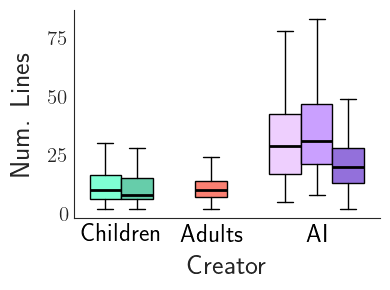

In [12]:
measure = "number_of_lines"
values = [product[product["subgroup"] == x][measure] for x in subgroups]
significance_test(values)
boxplot(values, measure, 7, "Num. Lines")

### Inverted

In [13]:
print(product[product["creator"] == "children"][["stimuli", "inverted"]].groupby("stimuli").mean()["inverted"].to_dict())
print(product[product["creator"] == "children"][["subgroup", "inverted"]].groupby("subgroup").mean()["inverted"].to_dict())

{'G': 0.20945945945945946, 'I': 0.12837837837837837, 'R': 0.6081081081081081}
{'pre-schematic': 0.30158730158730157, 'schematic': 0.3333333333333333}


### Used Mask

In [14]:
measure = "used_stimulus"
values = [product[product["creator"] == x][measure] for x in creators]
significance_test(values)
print(product[["creator", measure]].groupby("creator").mean())


Performing Kruskal-Wallis Test:
Test Statistic: 450.10901532236534
p-value: 1.819990811107293e-98
The groups are significantly different:
              1             2             3
1  1.000000e+00  1.000000e+00  2.059510e-72
2  1.000000e+00  1.000000e+00  5.060521e-77
3  2.059510e-72  5.060521e-77  1.000000e+00
          used_stimulus
creator                
AI             0.485556
adults         0.934685
children       0.911036


## 2. Content

### Conceptual Diversity

Total categories: 253


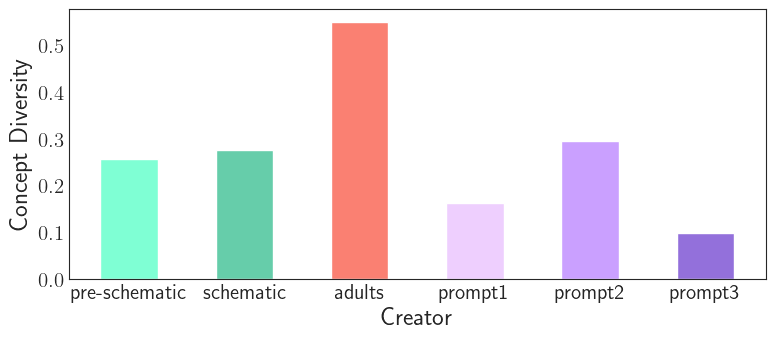

In [15]:
p = inflect.engine()
total_categories = len(set([singularize_word(x.replace("(s)", "")).strip().lower() for x in product["category1"].dropna().tolist() + product["category2"].dropna().tolist() + product["category3"].dropna().tolist()]))
print("Total categories:", total_categories)
categories = {x: set([singularize_word(x.replace("(s)", "")).strip().lower() for x in product[product["subgroup"] == x]["category1"].dropna().tolist() + product[product["subgroup"] == x]["category2"].dropna().tolist() + product[product["subgroup"] == x]["category3"].dropna().tolist()]) for x in subgroups}
diversities = [len(categories[x])/total_categories for x in subgroups]

plt.figure(figsize=(9, 3.5))
plt.bar(subgroups, diversities, color=colors, width=0.5)
plt.ylabel("Concept Diversity")
plt.xlabel("Creator")
plt.savefig("../../figures/concept_diversity.png", bbox_inches='tight', dpi=1000)

In [16]:
print("Prompt 1 themes:", ", ".join(categories["prompt1"]))
print("Prompt 2 themes:", ", ".join(categories["prompt2"])) # more objects
print("Prompt 3 themes:", ", ".join(categories["prompt3"])) # more living

Prompt 1 themes: snake, sun, maze, frame, lamp, sculpture, skiscaper, river, face, glas, house, writing, table, curtain, plant, letter, abstract doodle/hard to interpret, mountain, bug, bag, mounatin, person, painting, heart, moon, raindrop, tree, park, city, window, pattern, flower, fruit, glass, tent, door, arch, helmet, baloon, eye, diamond
Prompt 2 themes: umbrella, book, bench, rain, mobile phone, sun, building, bowl, plate, cat, globe, knife, container, frame, bottle, lamp, candle, pineapple, trash container, bed, face, bookshelf, watering can, hand, bu, glas, pen, booth, chair, writing, trashcan, car, table, curtain, plant, present, toast, lock, cloud, light bulb, abstract doodle/hard to interpret, desk, wine glass, can, mountain, bag, platter with lid, vase, person, painting, tooth brush, moon, tree, computer mouse, city, cup, window, keyboard, display, flower, fruit, kettle, shelf, leg, smiley face, door, path, digital device, food, arch, dresser, trashbag, straw, house, trash

### Theme Visualisation

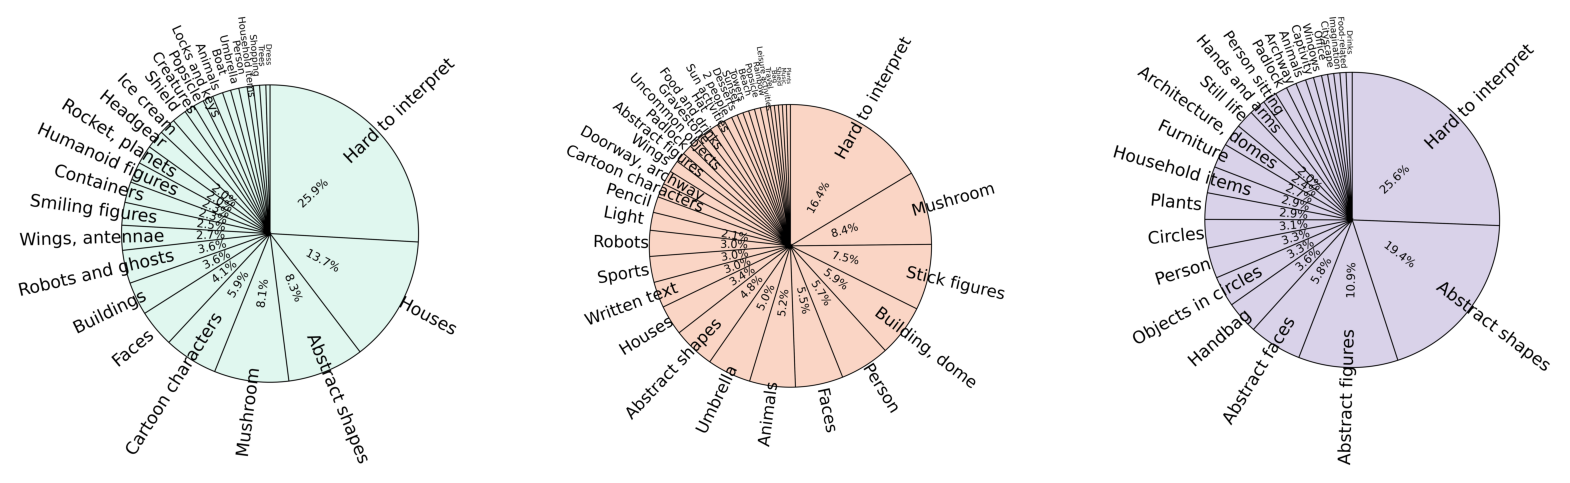

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20,8))
ax[0].imshow(Image.open("../../figures/pie_chart_children.png"))
ax[0].axis("off")
ax[1].imshow(Image.open("../../figures/pie_chart_adults.png"))
ax[1].axis("off")
ax[2].imshow(Image.open("../../figures/pie_chart_AI.png"))
ax[2].axis("off");

## 3. Process

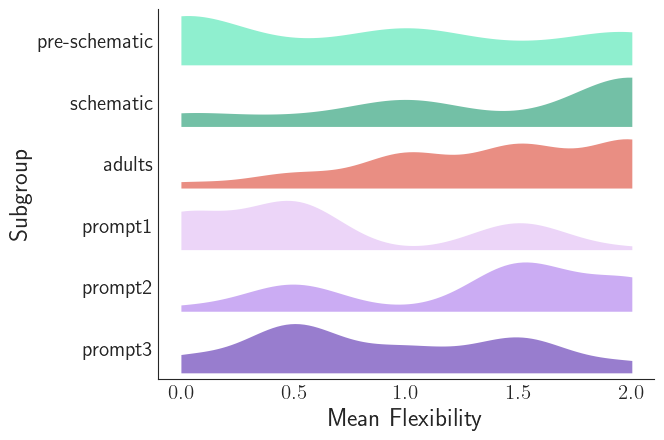

In [18]:
df_process = pd.concat([children_process[["mean_flexibility", "subgroup"]], adults_process[["mean_flexibility", "subgroup"]], AI_process[["mean_flexibility", "subgroup"]]], ignore_index=True)

for i, subgroup in enumerate(subgroups):
    sns.violinplot(x=df_process[df_process["subgroup"] == subgroup]["mean_flexibility"], y=[subgroup] * len(df_process[df_process["subgroup"] == subgroup]), scale="width", inner=None, linewidth=0, cut=0, bw=0.35, color=colors[i], split=True)


xticks = np.arange(df_process["mean_flexibility"].min(), df_process["mean_flexibility"].max() + 0.5, 0.5)
plt.xticks(xticks)
plt.xlabel('Mean Flexibility')
plt.ylabel('Subgroup')
sns.despine(right=True)
plt.grid(False)
plt.savefig("../../figures/process.png", bbox_inches='tight', dpi=1000)

# image sets used for AI:
# np.random.seed(34)
# image1 = ["../../data/AI/prompt_1/stimuli_G/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_1/stimuli_G/"))) if x != ".DS_Store"] + \
#         ["../../data/AI/prompt_2/stimuli_G/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_2/stimuli_G/"))) if x != ".DS_Store"] + \
#         ["../../data/AI/prompt_3/stimuli_G/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_3/stimuli_G/"))) if x != ".DS_Store"]

# image2 = ["../../data/AI/prompt_1/stimuli_I/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_1/stimuli_I/"))) if x != ".DS_Store"] + \
#         ["../../data/AI/prompt_2/stimuli_I/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_2/stimuli_I/"))) if x != ".DS_Store"] + \
#         ["../../data/AI/prompt_3/stimuli_I/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_3/stimuli_I/"))) if x != ".DS_Store"]

# image3 = ["../../data/AI/prompt_1/stimuli_R/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_1/stimuli_R/"))) if x != ".DS_Store"] + \
#         ["../../data/AI/prompt_2/stimuli_R/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_2/stimuli_R/"))) if x != ".DS_Store"] + \
#         ["../../data/AI/prompt_3/stimuli_R/" + x for x in list(np.random.permutation(os.listdir("../../data/AI/prompt_3/stimuli_R/"))) if x != ".DS_Store"]

In [19]:
significance_test([children_process[children_process["subgroup"] == "pre-schematic"]["mean_flexibility"], children_process[children_process["subgroup"] == "schematic"]["mean_flexibility"], adults_process["mean_flexibility"], AI_process[AI_process["subgroup"] == "prompt1"]["mean_flexibility"], AI_process[AI_process["subgroup"] == "prompt2"]["mean_flexibility"], AI_process[AI_process["subgroup"] == "prompt3"]["mean_flexibility"]])


Performing Kruskal-Wallis Test:
Test Statistic: 24.501559950938482
p-value: 4.7813865731085125e-06
The groups are significantly different:
          1             2             3             4         5         6
1  1.000000  9.018347e-04  1.195459e-05  3.810747e-01  0.011940  1.000000
2  0.000902  1.000000e+00  1.000000e+00  2.515654e-07  1.000000  0.005339
3  0.000012  1.000000e+00  1.000000e+00  7.906280e-10  1.000000  0.000452
4  0.381075  2.515654e-07  7.906280e-10  1.000000e+00  0.000009  0.758648
5  0.011940  1.000000e+00  1.000000e+00  8.970898e-06  1.000000  0.035867
6  1.000000  5.339251e-03  4.515816e-04  7.586475e-01  0.035867  1.000000


# Q2. Who is More Creative

## ICC

In [20]:
calculate_icc(product["creativity"], product["creativity2"])

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.586564,3.837505,1337,1338,6.015137e-125,"[0.55, 0.62]"
1,ICC2,Single random raters,0.611181,5.531768,1337,1337,3.817089e-193,"[0.32, 0.76]"
2,ICC3,Single fixed raters,0.693804,5.531768,1337,1337,3.817089e-193,"[0.66, 0.72]"
3,ICC1k,Average raters absolute,0.739414,3.837505,1337,1338,6.015137e-125,"[0.71, 0.77]"
4,ICC2k,Average random raters,0.758675,5.531768,1337,1337,3.817089e-193,"[0.49, 0.86]"
5,ICC3k,Average fixed raters,0.819226,5.531768,1337,1337,3.817089e-193,"[0.8, 0.84]"


In [21]:
calculate_icc(product["originality_audra"], product["originality_ocs"])

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.790068,8.526907,1337,1338,6.681050e-287,"[0.77, 0.81]"
1,ICC2,Single random raters,0.793871,10.345204,1337,1337,0.000000e+00,"[0.68, 0.86]"
2,ICC3,Single fixed raters,0.823714,10.345204,1337,1337,0.000000e+00,"[0.81, 0.84]"
3,ICC1k,Average raters absolute,0.882724,8.526907,1337,1338,6.681050e-287,"[0.87, 0.89]"
4,ICC2k,Average random raters,0.885093,10.345204,1337,1337,0.000000e+00,"[0.81, 0.92]"
5,ICC3k,Average fixed raters,0.903337,10.345204,1337,1337,0.000000e+00,"[0.89, 0.91]"


In [22]:
calculate_icc(product["mean_creativity"], product["mean_originality"])

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.147794,1.346849,1337,1338,2.754511e-08,"[0.09, 0.2]"
1,ICC2,Single random raters,0.247197,1.951636,1337,1337,4.585104e-34,"[0.07, 0.39]"
2,ICC3,Single fixed raters,0.322410,1.951636,1337,1337,4.585104e-34,"[0.27, 0.37]"
3,ICC1k,Average raters absolute,0.257526,1.346849,1337,1338,2.754511e-08,"[0.17, 0.33]"
4,ICC2k,Average random raters,0.396404,1.951636,1337,1337,4.585104e-34,"[0.12, 0.57]"
5,ICC3k,Average fixed raters,0.487609,1.951636,1337,1337,4.585104e-34,"[0.43, 0.54]"


In [23]:
print(get_spearman_corr(product["creativity"], product["creativity2"]))
print(get_spearman_corr(product["originality_audra"], product["originality_ocs"]))
print(get_spearman_corr(product["mean_creativity"], product["mean_originality"]))

SignificanceResult(statistic=0.6930571627124863, pvalue=4.02616311478547e-192)
SignificanceResult(statistic=0.8246612402380925, pvalue=0.0)
SignificanceResult(statistic=0.36095983204774096, pvalue=1.909109613444619e-42)


In [24]:
print(get_spearman_corr(product[product["subgroup"] == "adults"]["mean_creativity"], product[product["subgroup"] == "adults"]["mean_originality"]))

print(get_spearman_corr(product[product["subgroup"] == "pre-schematic"]["mean_creativity"], product[product["subgroup"] == "pre-schematic"]["mean_originality"]))
print(get_spearman_corr(product[product["subgroup"] == "schematic"]["mean_creativity"], product[product["subgroup"] == "schematic"]["mean_originality"]))
print(get_spearman_corr(product[product["subgroup"] == "prompt1"]["mean_creativity"], product[product["subgroup"] == "prompt1"]["mean_originality"]))
print(get_spearman_corr(product[product["subgroup"] == "prompt2"]["mean_creativity"], product[product["subgroup"] == "prompt2"]["mean_originality"]))
print(get_spearman_corr(product[product["subgroup"] == "prompt3"]["mean_creativity"], product[product["subgroup"] == "prompt3"]["mean_originality"]))

SignificanceResult(statistic=0.6566224964451297, pvalue=4.114986115840513e-56)
SignificanceResult(statistic=0.5634952953481459, pvalue=1.6169811466424865e-22)
SignificanceResult(statistic=0.641706934714616, pvalue=1.140813661392859e-23)
SignificanceResult(statistic=0.2710741390041851, pvalue=0.000792957694629266)
SignificanceResult(statistic=0.2621712365109397, pvalue=0.0011913209833465416)
SignificanceResult(statistic=0.1992607023611111, pvalue=0.014501840723433768)


## Correlations

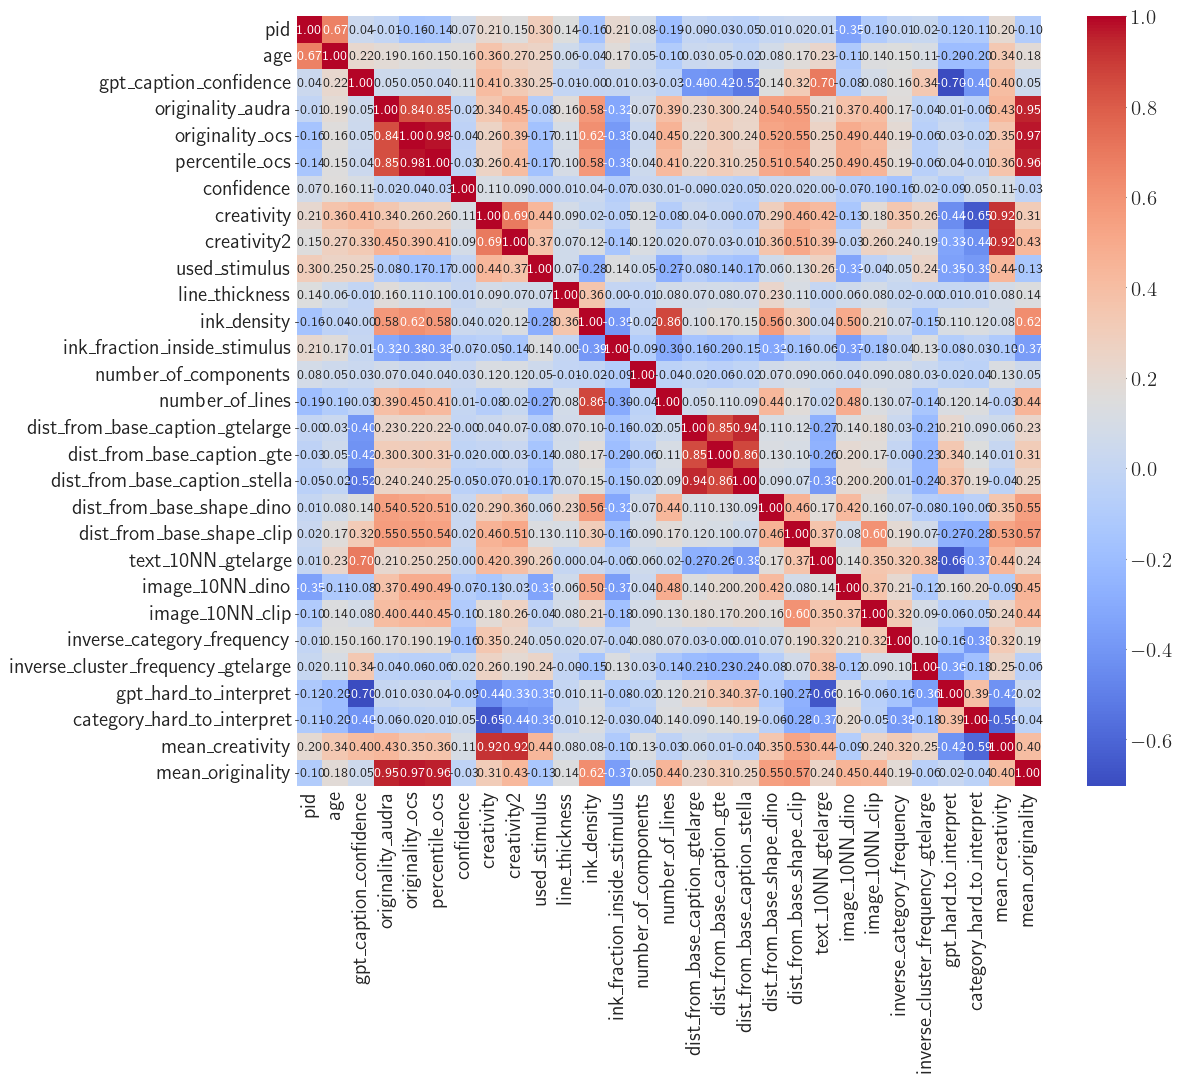

In [25]:
numeric_product = product.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
correlation_matrix = numeric_product.corr(method="pearson")
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Example Images

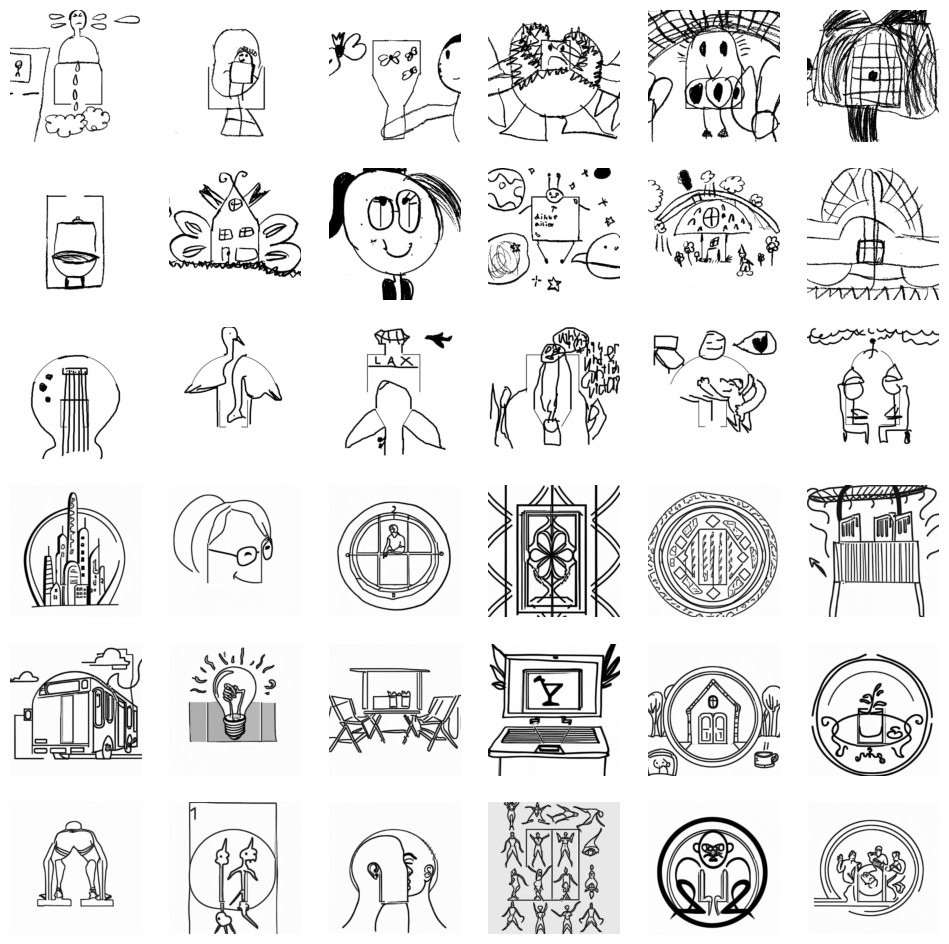

In [26]:
expert = product.sort_values(by="mean_creativity", ascending=False).groupby("subgroup").agg(list)
automated = product.sort_values(by="mean_originality", ascending=False).groupby("subgroup").agg(list)

fig, ax = plt.subplots(6, 6, figsize=(12,12))
for i, s in enumerate(subgroups):
    for j in range(6):
        if j < 3:
            ax[i, j].imshow(Image.open("../" + expert.loc[s]["filepath"][j]), cmap="gray")
        if j > 2:
            ax[i, j].imshow(Image.open("../" + automated.loc[s]["filepath"][j-3]), cmap="gray")
        ax[i,j].axis("off")